In [24]:

import pandas as pd

   # Завантаження даних
df = pd.read_csv('D:\\Kozhan\\Практичні роботи\\Thema_3\\practike_3_3\\archive\\russia_losses_equipment.csv')

   # Перегляд перших рядків
print(df.head())
   
   # Огляд інформації про набір даних
print(df.info())








         date   day  aircraft  helicopter   tank    APC  field artillery  \
0  2026-09-12  1662       442         356  12342  25322            49601   
1  2026-09-11  1661       441         356  12341  25312            49516   
2  2026-09-10  1660       441         356  12339  25305            49452   
3  2026-09-09  1659       441         355  12338  25290            49383   
4  2026-09-08  1658       441         355  12332  25285            49341   

    MRL  military auto  fuel tank   drone  naval ship  anti-aircraft warfare  \
0  2115            NaN        NaN  512175          35                   1633   
1  2109            NaN        NaN  510130          35                   1622   
2  2107            NaN        NaN  508205          35                   1618   
3  2105            NaN        NaN  506188          35                   1613   
4  2104            NaN        NaN  504309          35                   1612   

   special equipment  mobile SRBM system greatest losses direc

In [27]:
# 1. Перевірка на пропущені значення
print("Пропущені значення до обробки:")
print(df.isnull().sum())

# 2. Заповнення пропущених значень середнім МОВЧКИ для числових стовпців
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# 3. Видалення дублікатів
df.drop_duplicates(inplace=True)

# 4. Автоматичне перетворення ВСІХ текстових/категоріальних колонок на числові коди
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

# 5. Підсумкова перевірка
print("\nПропущені значення після обробки:")
print(df.isnull().sum())

Пропущені значення до обробки:
date                            0
day                             0
aircraft                        0
helicopter                      0
tank                            0
APC                             0
field artillery                 0
MRL                             0
military auto                1596
fuel tank                    1596
drone                           0
naval ship                      0
anti-aircraft warfare           0
special equipment              19
mobile SRBM system           1625
greatest losses direction    1458
vehicles and fuel tanks        65
cruise missiles                65
submarines                    566
ground robotic systems       1528
dtype: int64

Пропущені значення після обробки:
date                         0
day                          0
aircraft                     0
helicopter                   0
tank                         0
APC                          0
field artillery              0
MRL                     

In [28]:
print(df.describe())


              date          day     aircraft   helicopter          tank  \
count  1661.000000  1661.000000  1661.000000  1661.000000   1661.000000   
mean    830.000000   832.000000   342.251054   303.039735   7217.219747   
std     479.633714   479.633714    79.614645    60.650616   3811.475716   
min       0.000000     2.000000    10.000000     7.000000     80.000000   
25%     415.000000   417.000000   308.000000   293.000000   3657.000000   
50%     830.000000   832.000000   357.000000   326.000000   7794.000000   
75%    1245.000000  1247.000000   421.000000   340.000000  11046.000000   
max    1660.000000  1662.000000   442.000000   356.000000  12342.000000   

                APC  field artillery          MRL  military auto    fuel tank  \
count   1661.000000      1661.000000  1661.000000    1661.000000  1661.000000   
mean   14646.916315     17362.726069  1027.953642    1047.507692    69.323077   
std     7902.747094     14929.875322   533.799741      91.531982     1.481658   


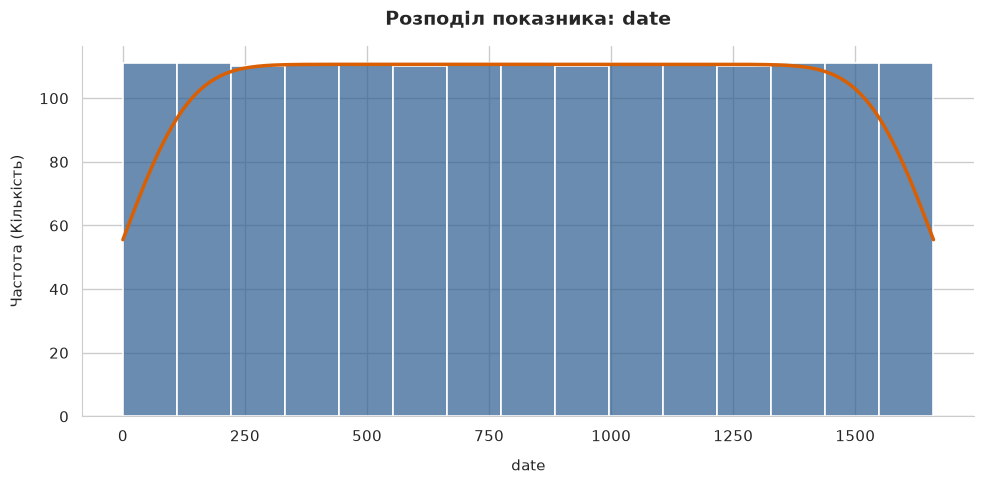

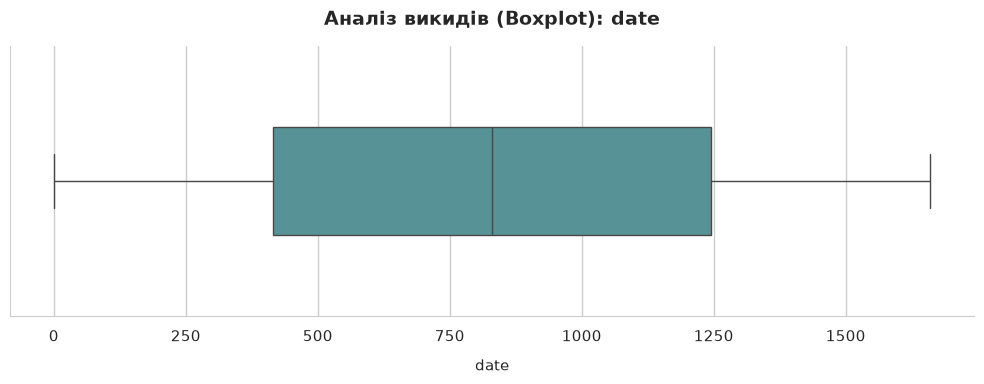

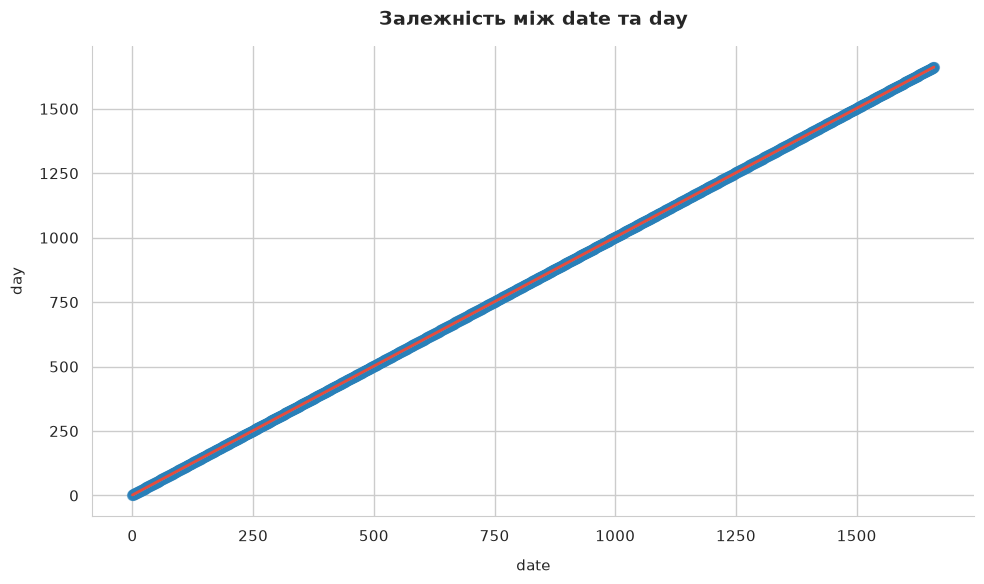

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Налаштування загального стилю
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Отримуємо числові колонки
num_cols = df.select_dtypes(include=['number']).columns

if len(num_cols) >= 1:
    col1 = num_cols[0]
    
    # ----------------------------------------------------
    # 1. Гістограма з кривою щільності (KDE)
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(
        df[col1], 
        bins=15, 
        kde=True, 
        color="#2b5c8f", 
        edgecolor="white", 
        linewidth=1.2,
        alpha=0.7,
        ax=ax
    )
    
    # Налаштування стилю ліній KDE
    if ax.lines:
        ax.lines[0].set_color('#d95f02')
        ax.lines[0].set_linewidth(2.5)

    ax.set_title(f'Розподіл показника: {col1}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(col1, fontsize=11, labelpad=10)
    ax.set_ylabel('Частота (Кількість)', fontsize=11, labelpad=10)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------
    # 2. Коробкова діаграма (Boxplot) для аналізу викидів
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(
        x=df[col1], 
        color="#4c9da0", 
        fliersize=5, 
        flierprops={"marker": "o", "markerfacecolor": "#e74c3c", "markeredgecolor": "none"},
        width=0.4,
        ax=ax
    )
    
    ax.set_title(f'Аналіз викидів (Boxplot): {col1}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(col1, fontsize=11, labelpad=10)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

if len(num_cols) >= 2:
    col2 = num_cols[1]
    
    # ----------------------------------------------------
    # 3. Діаграма розсіювання (Scatterplot) з трендом
    # ----------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.regplot(
        data=df, 
        x=col1, 
        y=col2, 
        color="#34495e",
        scatter_kws={'alpha': 0.6, 's': 50, 'color': '#2980b9'},
        line_kws={'color': '#e74c3c', 'linewidth': 2},
        ax=ax
    )
    
    ax.set_title(f'Залежність між {col1} та {col2}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(col1, fontsize=11, labelpad=10)
    ax.set_ylabel(col2, fontsize=11, labelpad=10)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

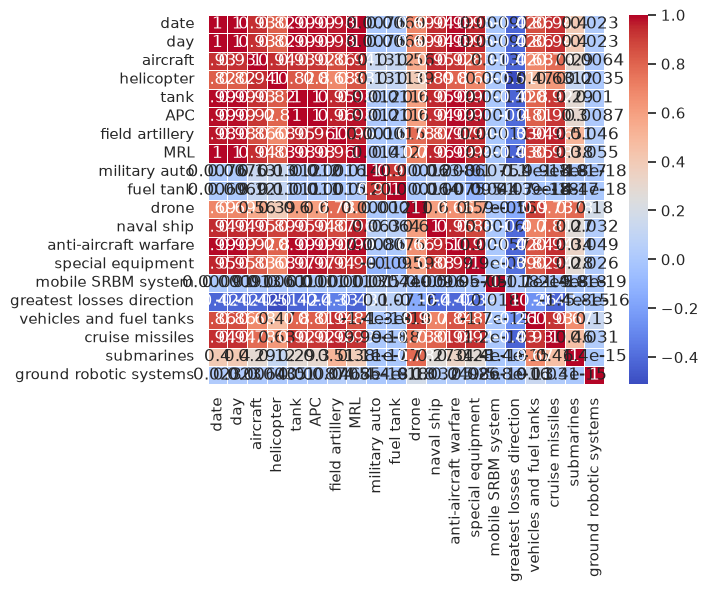

In [33]:

   # Кореляційна матриця
correlation_matrix = df.corr()

   # Візуалізація кореляційної матриці
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()
